<font color="FF3B3B"><h1 align="left">Proyecto de aprendizaje profundo</h1></font>
<font color="#6E6E6E"><h2 align="left">Modelo complejo CNN Nº 4.5</h2></font>

##### David Alejandro Pedroza De Jesús
##### Joel Ezequiel Vicente Alonso

Cargamos las librerias para la realización del proyecto

In [4]:
import sys
sys.path.append("../")
from modelos.CNNComplejo4_5 import ModeloComplejo
import numpy as np
import pandas as pd
import cv2
import kagglehub
import os
from shutil import move
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import plot_model

# Resumen

Hemos añadido un bach normalization a cada capa de conv, esto no solo normaliza la salida de cada capa de `conv2d` si no que también regulariza.

# Cargar las imagenes

Hararemos el procesado que hemos hecho antes, tanto con las etiquetas e imagenes.

In [5]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")
print(path)

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
/kaggle/input/cards-image-datasetclassification


In [7]:
#move(path,os.getcwd())

In [ ]:
#os.rename("2","cards-image-datasetclassification")

In [12]:
datos = pd.read_csv(r"cards-image-datasetclassification/cards.csv")
datos.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


Arreglamos las rutas.

In [13]:
rutas_adaptadas = ["cards-image-datasetclassification/" +  ruta for ruta in datos["filepaths"]]
im_buenas = []
im_malas = []
for ru in rutas_adaptadas:
    im = cv2.imread(ru)
    if  im is not None:
        im_buenas.append(ru)
    else:
        im_malas.append(ru)
#print(f"Lecturas correctas: {len(im_buenas)}")
#print(f"Lecturas incorrectas: {len(im_malas)}")

df_limpio = datos[np.array(rutas_adaptadas) != np.array(im_malas)]
df_limpio["rutas_adap"] = im_buenas

/tmp/ipykernel_514/1813950221.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["rutas_adap"] = im_buenas


Ahora cargamos las imagenes, añadiremos un procesado más, debido a que no necesitamos toda la carta para realizar la predicción.

In [14]:
def CargarImg(path, size):
    img = cv2.imread(path)
    img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)[0:75,0:75]#De con esto ya tenemos toda la información
    img_resize = cv2.resize(img_RGB, size)
    return np.array(img_resize / 255.)

In [15]:
rutas_train = df_limpio[df_limpio["data set"] == "train"].rutas_adap
rutas_test = df_limpio[df_limpio["data set"] == "test"].rutas_adap
rutas_val = df_limpio[df_limpio["data set"] == "valid"].rutas_adap

X_train = np.array([CargarImg(path, (75, 75)) for path in rutas_train])
X_test = np.array([CargarImg(path, (75, 75)) for path in rutas_test])
X_val = np.array([CargarImg(path, (75, 75)) for path in rutas_val])

y_train = df_limpio[df_limpio["data set"] == "train"]["labels"]
y_test = df_limpio[df_limpio["data set"] == "test"]["labels"]
y_val = df_limpio[df_limpio["data set"] == "valid"]["labels"]

Y codificamos los labels con `LabelEncoder()`

In [16]:
encoder = LabelEncoder()

y_train_num = encoder.fit_transform(y_train)
y_val_num   = encoder.transform(y_val)
y_test_num  = encoder.transform(y_test)

# Arquitectura de la red

En este apartado iremos probando la arquitectura, en este hemos añadido capas dos capas dense y dos capas convolucionales.

In [17]:
input_shape = X_train[0].shape
num_clases = np.unique(y_train_num).shape[0]
model = ModeloComplejo(input_shape, num_clases)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 75, 75, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       663,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 53)             │        13,621 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 788,021 (3.01 MB)

 Trainable params: 787,573 (3.00 MB)

 Non-trainable params: 448 (1.75 KB)

También aquí hacemos un plot de la arquitectura del modelo.

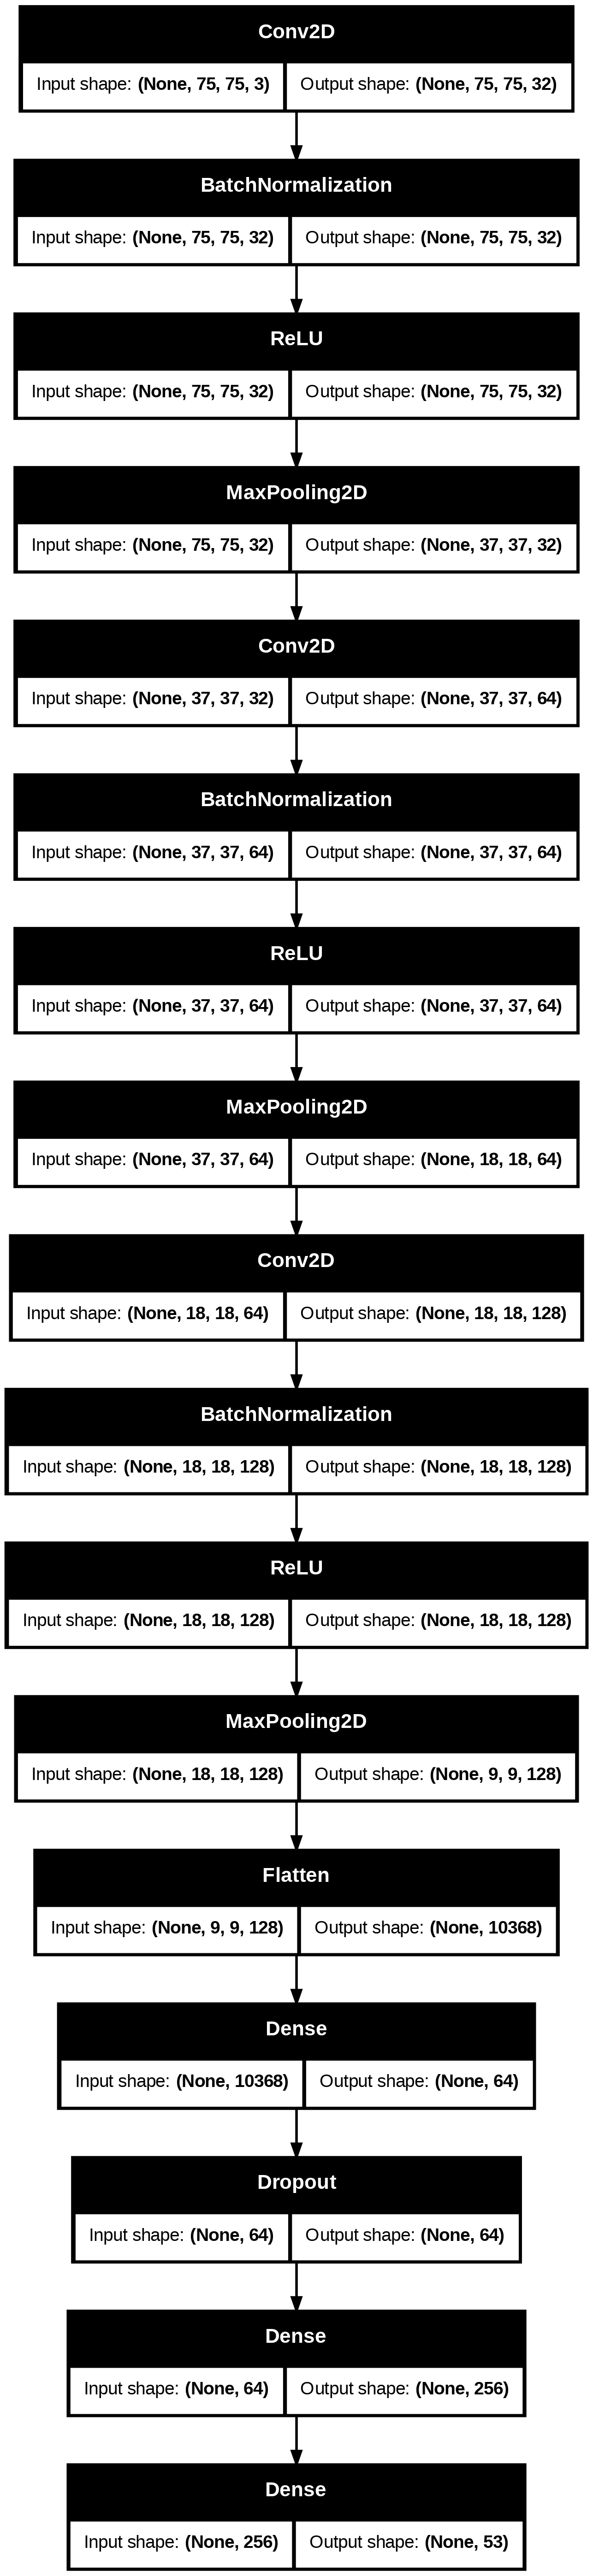

In [18]:
plot_model(model, show_shapes=True)

# Entrenamiento

En este apartado realizaremos el entrenamiento.En este caso en pruebas anteriores demostraron que este modelo requiere de más epocas para converger

In [19]:
hist = model.fit(X_train, y_train_num,validation_data=(X_val, y_val_num), epochs=200)

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 3.9199 - sparse_categorical_accuracy: 0.0241 - val_loss: 3.7819 - val_sparse_categorical_accuracy: 0.0377
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.7725 - sparse_categorical_accuracy: 0.0319 - val_loss: 3.6567 - val_sparse_categorical_accuracy: 0.0302
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.7128 - sparse_categorical_accuracy: 0.0384 - val_loss: 3.6247 - val_sparse_categorical_accuracy: 0.0302
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.6967 - sparse_categorical_accuracy: 0.0341 - val_loss: 3.6127 - val_sparse_categorical_accuracy: 0.0340
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.6481 - sparse_categorical_accuracy: 0.0371 - val_loss: 3.5572 - val_sparse_categorical_accuracy: 0.0340
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.5590 - sparse_categorical_accuracy: 0.0488 - val_loss: 3.4703 - val_sparse_categorical_accuracy:

# Evaluación del modelo

Este modelo funciona un poco mejor con respecto al anterior, debido a que el error se ha reducido y el acc mejoró un poco.

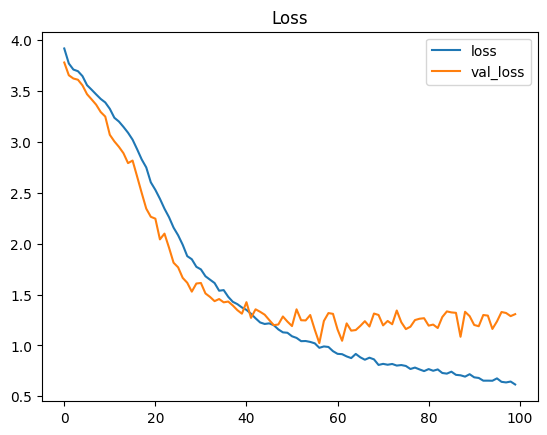

In [20]:
loss = hist.history["loss"]
val_loss = hist.history["val_loss"]

plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.legend()
plt.show()

Como se ha dicho antes el acc ha aumentado un poco más.

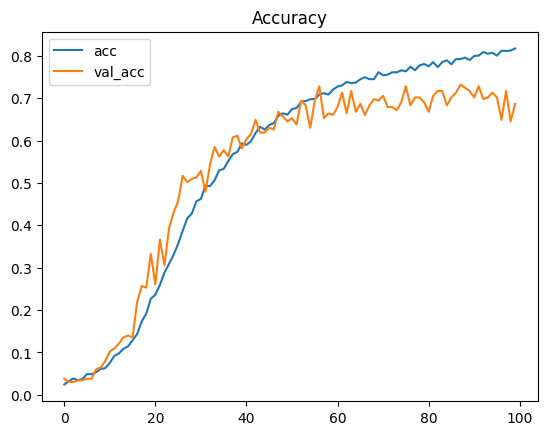

In [21]:
acc = hist.history["sparse_categorical_accuracy"]
val_acc = hist.history["val_sparse_categorical_accuracy"]

plt.plot(acc, label="acc")
plt.plot(val_acc, label="val_acc")
plt.title("Accuracy")
plt.legend()
plt.show()

El modelo funciona muy bien tanto en validación como en test, lo que indica que vamos por buen camino a la hora de crear una arquitectura buena para resolver este problema.

In [22]:

train_loss, train_acc = model.evaluate(X_train, y_train_num, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_num, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_num, verbose=0)

print("TRAIN:")
print("Loss:", round(train_loss,3))
print("Accuracy:", round(train_acc,3))

print("\nVALIDATION:")
print("Loss:", round(val_loss,3))
print("Accuracy:", round(val_acc,3))

print("\nTEST:")
print("Loss:", round(test_loss,3))
print("Accuracy:", round(test_acc,3))

TRAIN:
Loss: 0.29
Accuracy: 0.927

VALIDATION:
Loss: 1.308
Accuracy: 0.687

TEST:
Loss: 1.586
Accuracy: 0.679


# Matriz de confución

Si miramos la matriz de confusión, el modelo funciona razonablemente bien, recordemos que es para detección de cartas; pero aun hay mucho margen de mejora.

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


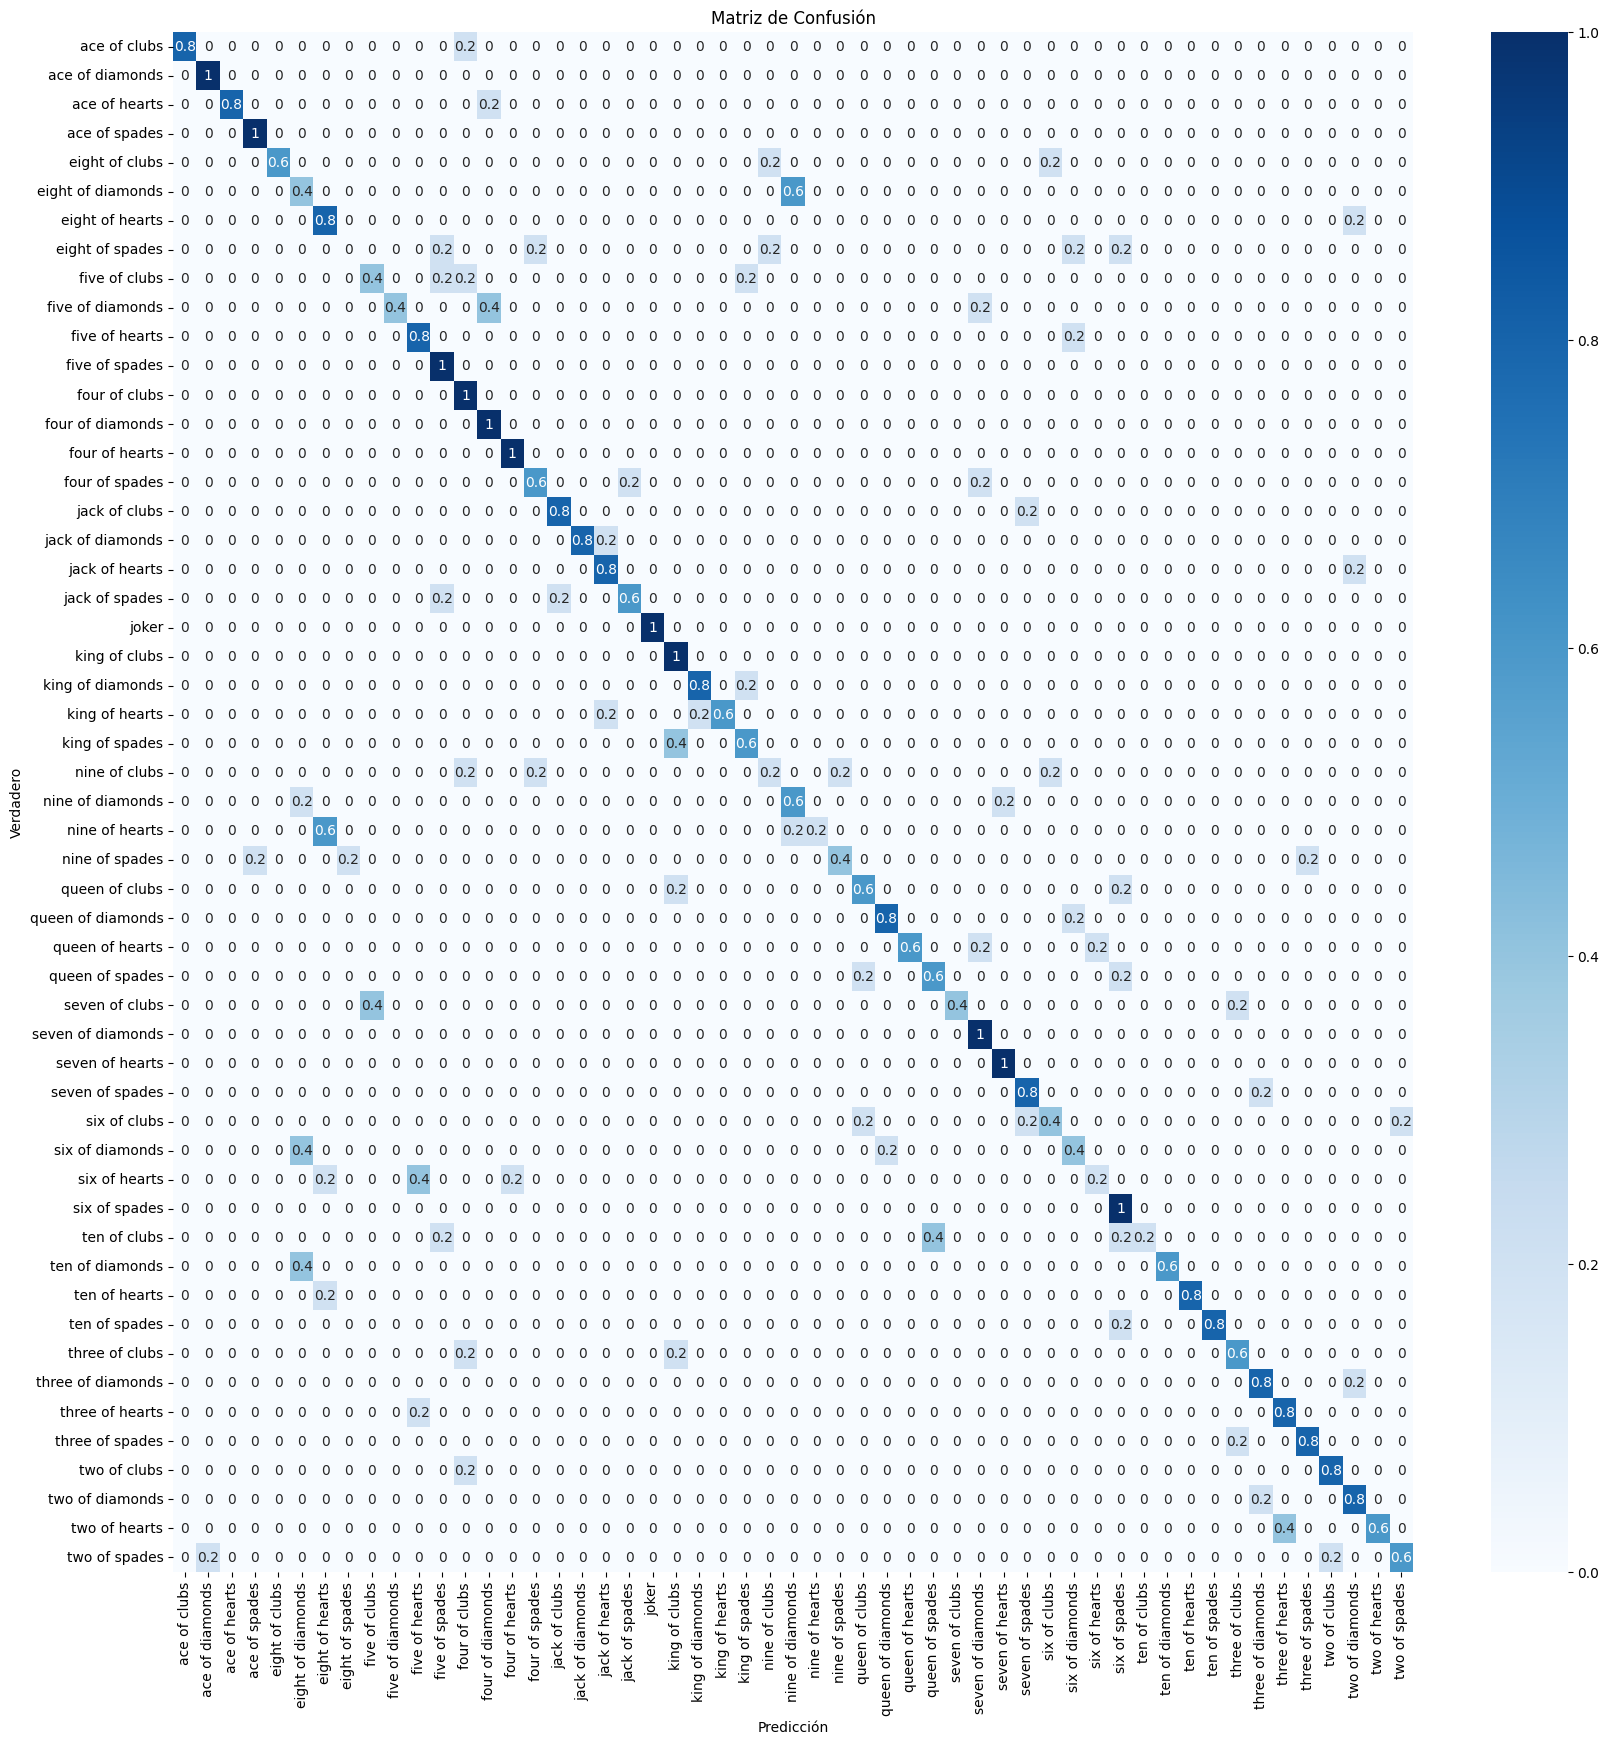

In [23]:
class_names = encoder.classes_

cm = confusion_matrix(y_test_num, np.argmax(model.predict(X_test), axis=1), normalize="true")

plt.figure(figsize=(20, 20))
sns.heatmap(cm,
            annot=True, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)

plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.yticks(rotation=0)
plt.show()

# Conclusión

El modelo aun parece tener margen de mejora, el proximo paso podría ser añadir más capas o incluso regularizar un poco más.